In [1]:
import shutil
from pathlib import Path
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


In [102]:
%pip install torchvision

^C
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# candidate_dirs = [
#     "data/custom_dataset/splits/access_v1",
#     "../data/custom_dataset/splits/access_v1",
#     "../../data/custom_dataset/splits/access_v1",
# ]

# # use Path so slash-operator (/) works as intended
# SPLIT_ROOT = Path("C:/Users/ASUS/Desktop/MachineLearning/git/data/custom_dataset/splits/access_v1")

# print(f"Using data folder: {SPLIT_ROOT}")
# LABELS = ["accept", "reject"]

# for split in ["train", "val", "test"]:
#     split_dir = SPLIT_ROOT / split
#     if not split_dir.exists():
#         raise FileNotFoundError(f"Missing split folder: {split_dir}")
#     for label in LABELS:
#         (split_dir / label).mkdir(parents=True, exist_ok=True)

#     for img_path in split_dir.glob("*.png"):
#         label = img_path.stem.split("_", 1)[0]
#         dest = split_dir / label / img_path.name
#         if not dest.exists():
#             shutil.move(img_path, dest)

Using data folder: C:\Users\ASUS\Desktop\MachineLearning\git\data\custom_dataset\splits\access_v1


In [ ]:
# # Rescaling to [0, 1] (tutorial step)
# base_transform = transforms.Compose([
#     transforms.Resize((128, 128)),
#     transforms.ToTensor(),  # converts PNGs to floats in [0, 1]
# ])

# train_data = datasets.ImageFolder(SPLIT_ROOT / "train", transform=base_transform)
# val_data = datasets.ImageFolder(SPLIT_ROOT / "val", transform=base_transform)
# test_data = datasets.ImageFolder(SPLIT_ROOT / "test", transform=base_transform)

# train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
# val_loader = DataLoader(val_data, batch_size=32)
# test_loader = DataLoader(test_data, batch_size=32)

# print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")
# print("Classes:", train_data.classes)


Train: 10596 | Val: 1324 | Test: 1325
Classes: ['accept', 'reject']


In [ ]:
# # Cropping + adjusting augmentations for training only
# train_transform = transforms.Compose([
#     transforms.RandomResizedCrop(128, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.ToTensor(),
# ])

# train_data = datasets.ImageFolder(SPLIT_ROOT / "train", transform=train_transform)
# train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
# print("Augmented training set ready:", len(train_data), "samples")


Augmented training set ready: 10596 samples


In [ ]:
# batch, labels = next(iter(train_loader))
# print("Batch tensor shape:", batch.shape)
# print("Label tensor shape:", labels.shape)
# print(f"Pixel value range after transforms: {batch.min().item():.3f} to {batch.max().item():.3f}")


Batch tensor shape: torch.Size([32, 3, 128, 128])
Label tensor shape: torch.Size([32])
Pixel value range after transforms: 0.000 to 0.996


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 10
BATCH_SIZE = 32
LEARNING_RATE = 1e-3

In [3]:
#============NEW============
SPLIT_ROOT = Path(
    "C:/Users/ASUS/Desktop/MachineLearning/git/processed_aug"
)  # <- your processed output folder

print(f"Using data folder: {SPLIT_ROOT}")

LABELS = ["accept", "reject"]

# verify structure
for split in ["train", "val", "test"]:
    split_dir = SPLIT_ROOT / split
    if not split_dir.exists():
        raise FileNotFoundError(f"Missing split folder: {split_dir}")

    for label in LABELS:
        label_dir = split_dir / label
        if not label_dir.exists():
            raise FileNotFoundError(f"Missing class folder: {label_dir}")

print("Directory structure is OK.")


Using data folder: C:\Users\ASUS\Desktop\MachineLearning\git\processed_aug
Directory structure is OK.


In [4]:
# simple base transform (used for val + test)
base_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# training augmentation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

In [5]:
train_data = datasets.ImageFolder(SPLIT_ROOT / "train", transform=train_transform)
val_data   = datasets.ImageFolder(SPLIT_ROOT / "val",   transform=base_transform)
test_data  = datasets.ImageFolder(SPLIT_ROOT / "test",  transform=base_transform)
# accept = datasets.ImageFolder(SPLIT_ROOT / "accept",  transform=base_transform)
# reject = datasets.ImageFolder(SPLIT_ROOT / "reject",  transform=base_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32)
test_loader  = DataLoader(test_data, batch_size=32)

from collections import Counter

def count_classes(dataset):
    # dataset.targets contains class indices (0 = accept, 1 = reject)
    counts = Counter(dataset.targets)
    class_names = dataset.classes  # ["accept", "reject"]
    return {class_names[i]: counts[i] for i in counts}

# Count per split
train_counts = count_classes(train_data)
val_counts   = count_classes(val_data)
test_counts  = count_classes(test_data)

print("Train:", train_counts)
print("Val:",   val_counts)
print("Test:",  test_counts)



Train: {'accept': 6128, 'reject': 6836}
Val: {'accept': 162, 'reject': 191}
Test: {'accept': 174, 'reject': 185}


In [6]:
#transformation for googlenet
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [44]:
import torch
import torch.nn as nn
from torchvision.models import googlenet, GoogLeNet_Weights

num_classes = 2  # accept / reject

model = googlenet(weights=GoogLeNet_Weights.IMAGENET1K_V1)

# Replace final classifier for your labels
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)
print(model)


GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [54]:
# Simple CNN: 2 conv blocks
class CNN_Tiny(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.classifier(self.features(x))
model = CNN_Tiny().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Total parameters: {total_params:,}")

CNN_Tiny(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=65536, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)
Total parameters: 8,408,386


In [25]:
# Simple CNN: 3 conv blocks 
class SimpleVoiceCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, len(LABELS)),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = SimpleVoiceCNN().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Total parameters: {total_params:,}")


SimpleVoiceCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)
Total parameters: 8,482,626


In [49]:
import torch
import torch.nn as nn
import torchvision.models as models

# ResNet34-based model
NUM_CLASSES = len(LABELS)
class VoiceResNet34(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        self.model = models.resnet34(weights="IMAGENET1K_V1")

        # Replace final layer
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

model = VoiceResNet34().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

VoiceResNet34(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [26]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


In [27]:
# Training loop (basic tutorial-style)
history = []
print(f"Model training on device: {model}")
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == targets).sum().item()
        total += targets.size(0)

    train_loss = running_loss / total
    train_acc = running_correct / total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    history.append({"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc, "val_loss": val_loss, "val_acc": val_acc})
    print(f"Epoch {epoch:02d} | Train loss {train_loss:.4f} acc {train_acc:.3f} | Val loss {val_loss:.4f} acc {val_acc:.3f}")


Model training on device: SimpleVoiceCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)
Epoch 01 | Train loss 0.3481 acc 0.837 | Val loss 0.2265 acc 0.898
Epoch 02 | Train loss 0.1725 acc 

KeyboardInterrupt: 

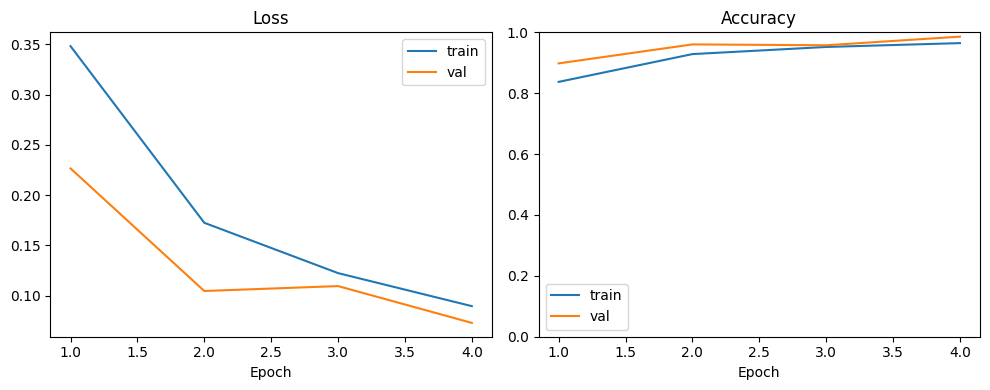

In [33]:
# Plot training curves
import matplotlib.pyplot as plt

epochs = [row["epoch"] for row in history]
train_losses = [row["train_loss"] for row in history]
val_losses = [row["val_loss"] for row in history]
train_accs = [row["train_acc"] for row in history]
val_accs = [row["val_acc"] for row in history]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="train")
plt.plot(epochs, val_losses, label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label="train")
plt.plot(epochs, val_accs, label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()
torch.save(model.state_dict(), 'simple_cnn_model.pth')


In [29]:
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            predicted = pred.argmax(dim=1)
            correct += (predicted == y).sum().item()
            total += y.size(0)
    return correct / total

print("Running final TEST evaluation...")
test_acc = evaluate(model, test_loader, device)
print(f"TEST Accuracy: {test_acc * 100:.2f}%")


Running final TEST evaluation...
TEST Accuracy: 79.39%


In [30]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for inputs, targets in val_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        outputs = model(inputs)
        preds = outputs.argmax(dim=1)

        correct += (preds == targets).sum().item()
        total += targets.size(0)

val_acc = correct / total
print("Val accuracy:", val_acc)


Val accuracy: 0.9518413597733711


In [31]:
from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_targets.extend(targets.tolist())

print(classification_report(all_targets, all_preds, target_names=LABELS, digits=4))


              precision    recall  f1-score   support

      accept     0.7016    1.0000    0.8246       174
      reject     1.0000    0.6000    0.7500       185

    accuracy                         0.7939       359
   macro avg     0.8508    0.8000    0.7873       359
weighted avg     0.8554    0.7939    0.7862       359



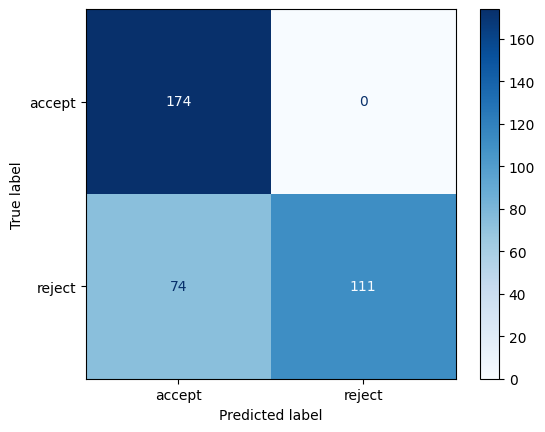

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_targets.extend(targets.tolist())

cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [32]:
model = SimpleVoiceCNN().to(device)
model.load_state_dict(torch.load('cnn_model.pth'))

<All keys matched successfully>

In [44]:
import sounddevice as sd
import numpy as np
import librosa
import torch
import threading
import datetime
from pathlib import Path
from scipy.io.wavfile import write
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, Markdown
from torchvision import transforms
import matplotlib.cm as cm

# --- SETTINGS ---
LABELS = ["accept", "reject"]
SR = 16000
CLIP_SECONDS = 3.0
N_MELS = 128
SILENCE_THRESHOLD = 0.01  # Silence threshold (RMS)
CONFIDENCE_THRESHOLD = 0.70 # Confidence threshold

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Model
try:
    model = SimpleVoiceCNN().to(device)
    model.load_state_dict(torch.load("simple_cnn_model.pth", map_location=device))
    model.eval()
except NameError:
    print("Error: Model not loaded into memory.")
except FileNotFoundError:
    print("Error: Model file not found.")

save_dir = Path("live_recordings")
save_dir.mkdir(exist_ok=True)
recording = []
is_recording = False

# --- PROCESSING ---

def audio_to_image_tensor(y, sr=16000):
    """
    Generates a spectrogram identical to your matplotlib code.
    - Bass at the TOP (as in your dataset).
    - Dynamic contrast (like plt.imshow default).
    - Stretching to 128x128 (like aspect='auto').
    """
    
    # 1. Mel Spectrogram (Your parameters)
    S = librosa.feature.melspectrogram(
        y=y, 
        sr=sr, 
        n_mels=128, 
        n_fft=2048, 
        hop_length=512
    )
    
    # 2. Power to dB (Your ref=np.max)
    # Makes the signal peak 0 dB.
    S_db = librosa.power_to_db(S, ref=np.max)

    # 3. plt.imshow emulation (Dynamic normalization)
    # Matplotlib takes min() and max() of the current image and stretches colors between them.
    min_val = S_db.min()
    max_val = S_db.max()
    
    # Protection against division by zero (if silence)
    if max_val - min_val < 1e-6:
        norm_S = np.zeros_like(S_db)
    else:
        norm_S = (S_db - min_val) / (max_val - min_val)

    # 4. Colors (Magma)
    cmap = cm.get_cmap("magma")
    img_array = (cmap(norm_S)[:, :, :3] * 255).astype(np.uint8)

    # 5. Orientation
    # In Librosa, index 0 = Bass.
    # In PIL, index 0 is drawn at the TOP.
    # Therefore, PIL naturally draws BASS AT THE TOP.
    # This matches your matplotlib code (where you did flip + lower, which also resulted in Bass at Top).
    # So flipud is NOT NEEDED here.
    img = Image.fromarray(img_array)
    
    # 6. Stretching (aspect='auto')
    # Your code saved the image as 128x128 regardless of audio length.
    # Resize does the same thing.
    img = img.resize((128, 128), resample=Image.Resampling.NEAREST)
    
    # Convert to tensor for the model
    t = transforms.ToTensor()(img).unsqueeze(0).to(device)
    
    return t, img

def is_silence(y, threshold=SILENCE_THRESHOLD):
    return np.sqrt(np.mean(y**2)) < threshold

# --- RECORDING LOGIC ---

def record_thread():
    global recording
    recording = []
    def callback(indata, frames, time, status):
        if is_recording: recording.append(indata.copy())
    with sd.InputStream(samplerate=SR, channels=1, callback=callback):
        while is_recording: sd.sleep(100)

output = widgets.Output()
button = widgets.Button(description="Start Recording", button_style="success", icon='microphone')

def on_click(b):
    global is_recording
    if not is_recording:
        is_recording = True
        b.description = "Stop Recording"
        b.button_style = "danger"
        threading.Thread(target=record_thread, daemon=True).start()
    else:
        is_recording = False
        b.description = "Start Recording"
        b.button_style = "success"
        
        if not recording: return

        y_raw = np.concatenate(recording).ravel()
        
        # Check for silence
        if is_silence(y_raw):
            with output:
                output.clear_output()
                print("⚠️ Too quiet (Silence)")
            return

        # Prepare audio (3 seconds)
        y, _ = librosa.effects.trim(y_raw, top_db=20)
        needed = int(CLIP_SECONDS * SR)
        if len(y) < needed: 
            # Note: This uses Right Padding as per your provided snippet. 
            # If you need Left Padding (for the dataset fix), swap to (needed-len, 0).
            y = np.pad(y, (0, needed - len(y)), mode='constant') 
        else: 
            y = y[:needed]

        # Generation and Prediction
        tensor_in, pil_img = audio_to_image_tensor(y, SR)
        
        with torch.no_grad():
            out = model(tensor_in)
            probs = torch.softmax(out, dim=1)[0]
            pred_idx = probs.argmax().item()
            conf = probs[pred_idx].item()

        label = LABELS[pred_idx]
        color = "green" if label == "accept" and conf > CONFIDENCE_THRESHOLD else "red"
        
        if conf < CONFIDENCE_THRESHOLD:
            label = f"{label} (Uncertain)"

        with output:
            output.clear_output()
            display(pil_img) # Look at the image: bright stripes should be at the TOP (bass)
            display(Markdown(f"### <span style='color:{color}'>{label}</span>"))
            display(Markdown(f"Confidence: **{conf:.1%}**"))

button.on_click(on_click)
display(button, output)

Button(button_style='success', description='Start Recording', icon='microphone', style=ButtonStyle())

Output()

In [45]:
%matplotlib inline
import sounddevice as sd
import numpy as np
import librosa
import torch
import threading
import datetime
import io
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from scipy.io.wavfile import write
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, Markdown
from torchvision import transforms

# --- SETTINGS ---
LABELS = ["accept", "reject"]
SR = 16000
CLIP_SECONDS = 3.0
N_MELS = 128
SILENCE_THRESHOLD = 0.01  # Silence threshold
CONFIDENCE_THRESHOLD = 0.70 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- MODEL LOADING ---
try:
    # Ensure the SimpleVoiceCNN class is defined in previous cells!
    model = SimpleVoiceCNN().to(device)
    model.load_state_dict(torch.load("cnn_model.pth", map_location=device))
    model.eval()
    print(f"✅ Model successfully loaded on {device}")
except NameError:
    print("❌ Error: SimpleVoiceCNN class not found. Run the model code cell first.")
except FileNotFoundError:
    print("❌ Error: cnn_model.pth file not found.")

save_dir = Path("live_recordings")
save_dir.mkdir(exist_ok=True)

recording = []
is_recording = False

# --- 1. CORRECT PREPROCESSING (LEFT PADDING) ---
def preprocess_audio(y, sr):
    """
    Trims silence and pads audio to 3 seconds.
    IMPORTANT: Adds silence to the LEFT to shift voice to the right (like in dataset).
    """
    # 1. Remove noise at edges
    y_trimmed, _ = librosa.effects.trim(y, top_db=20)
    
    needed_len = int(CLIP_SECONDS * sr)
    
    if len(y_trimmed) < needed_len:
        # LEFT PADDING (Zeros at the beginning)
        padding = needed_len - len(y_trimmed)
        y_final = np.pad(y_trimmed, (padding, 0), mode='constant')
    else:
        # If longer - take beginning (standard)
        y_final = y_trimmed[:needed_len]
        
    return y_final

# --- 2. GENERATION (EXACT MATCH VIA MATPLOTLIB) ---
def audio_to_image_tensor(y, sr=16000):
    """
    Generates spectrogram via Matplotlib Backend.
    Guarantees 100% match with dataset visual style.
    """
    # Mel calculation
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=2048, hop_length=512
    )
    S_db = librosa.power_to_db(S, ref=np.max)

    # Virtual figure (do not show on screen, draw to memory)
    # Using plt.figure without switch_backend, but closing manually
    fig = plt.figure(figsize=(1.28, 1.28), dpi=100)
    plt.axis("off")
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    
    # Drawing (Exactly as in dataset: flipud + origin lower)
    plt.imshow(S_db[::-1, :], aspect="auto", origin="lower",
               interpolation="nearest", cmap="magma")

    # Save to buffer
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches="tight", pad_inches=0)
    plt.close(fig) # Must close!
    
    # Read to PIL
    buf.seek(0)
    img = Image.open(buf).convert("RGB")
    
    # Resize (safety check)
    img = img.resize((128, 128), resample=Image.Resampling.NEAREST)
    
    # Tensor
    t = transforms.ToTensor()(img).unsqueeze(0).to(device)
    
    return t, img

# --- HELPER FUNCTIONS ---
def is_silence(y, threshold=SILENCE_THRESHOLD):
    return np.sqrt(np.mean(y**2)) < threshold

def record_thread():
    global recording
    recording = []
    def callback(indata, frames, time, status):
        if is_recording: recording.append(indata.copy())
    with sd.InputStream(samplerate=SR, channels=1, callback=callback):
        while is_recording: sd.sleep(100)

# --- INTERFACE ---
output = widgets.Output()
button = widgets.Button(description="Start Recording", button_style="success", icon='microphone')

def on_click(b):
    global is_recording
    if not is_recording:
        # START
        is_recording = True
        b.description = "Stop Recording"
        b.button_style = "danger"
        threading.Thread(target=record_thread, daemon=True).start()
    else:
        # STOP AND PROCESS
        is_recording = False
        b.description = "Start Recording"
        b.button_style = "success"
        
        if not recording: return

        # Concatenate recording
        y_raw = np.concatenate(recording).ravel()
        
        # 1. Absolute silence check (RMS)
        if is_silence(y_raw):
            with output:
                output.clear_output()
                print("⚠️ Too quiet (RMS check failed)")
            return

        # 2. Preprocessing (Trim + Left Padding)
        y = preprocess_audio(y_raw, SR)

        # 3. Save WAV (for logs)
        ts = datetime.datetime.now().strftime("%H%M%S")
        wav_path = save_dir / f"rec_{ts}.wav"
        write(wav_path, SR, (y * 32767).astype(np.int16))

        # 4. Image generation (Exact Match)
        tensor_in, pil_img = audio_to_image_tensor(y, SR)
        pil_img.save(save_dir / f"rec_{ts}.png") # Save PNG

        # 5. Inference
        with torch.no_grad():
            out = model(tensor_in)
            probs = torch.softmax(out, dim=1)[0]
            pred_idx = probs.argmax().item()
            conf = probs[pred_idx].item()

        label = LABELS[pred_idx]
        
        # Color logic
        color = "green" if label == "accept" and conf > CONFIDENCE_THRESHOLD else "red"
        label_text = label
        if conf < CONFIDENCE_THRESHOLD:
            label_text = f"{label} (Uncertain)"
            color = "orange"

        # Output results
        with output:
            output.clear_output()
            display(pil_img)
            display(Markdown(f"### Result: <span style='color:{color}'>**{label_text}**</span>"))
            display(Markdown(f"Confidence: **{conf:.1%}**"))
            display(Markdown(f"Saved: `{wav_path.name}`"))

button.on_click(on_click)
display(button, output)

✅ Model successfully loaded on cpu


Button(button_style='success', description='Start Recording', icon='microphone', style=ButtonStyle())

Output()

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import librosa
from PIL import Image
from torchvision import transforms
from pathlib import Path
import matplotlib.cm as cm
import glob


LABELS = ["accept", "reject"]
CONFIDENCE_THRESHOLD = 0.70


def _get_model_prediction(tensor_img):
    with torch.no_grad():
        out = model(tensor_img)
        probs = torch.softmax(out, dim=1)[0]
        pred_idx = probs.argmax().item()
        confidence = probs[pred_idx].item()
    return pred_idx, confidence, probs

def _plot_debug_info(pil_img, probs, original_type):
    img_array = np.array(pil_img)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # 1. Картинка
    axes[0].imshow(img_array)
    axes[0].set_title(f"Input ({original_type})\nShape: {pil_img.size}")
    axes[0].axis("off")

    # 2. Гистограмма
    axes[1].hist(img_array.ravel(), bins=50, color='purple', alpha=0.7)
    axes[1].set_title("Histogram of Pixel Values")
    
    # 3. Бары
    y_pos = np.arange(len(LABELS))
    probs_np = probs.cpu().numpy()
    bars = axes[2].bar(y_pos, probs_np, align='center', alpha=0.7, 
                       color=['green' if p > 0.5 else 'gray' for p in probs_np])
    axes[2].set_xticks(y_pos)
    axes[2].set_xticklabels(LABELS)
    axes[2].set_title("Prediction Probabilities")
    axes[2].set_ylim(0, 1)
    
    for bar in bars:
        height = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2%}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()


def debug_inference(input_data, sr=16000):
    pil_img = None
    original_type = "Unknown"

 
    if isinstance(input_data, (str, Path)):
        path = Path(input_data)
        if path.is_dir():
            print(f"Error")
            return
            
        if path.suffix.lower() == ".wav":
            original_type = "WAV File"
            y, _ = librosa.load(path, sr=sr)
            input_data = y 
        elif path.suffix.lower() == ".png":
            original_type = "PNG File"
            pil_img = Image.open(path).convert("RGB")
    
    if isinstance(input_data, np.ndarray) and pil_img is None:
        if input_data.ndim == 1:
            original_type = "Raw Audio Array"
            S = librosa.feature.melspectrogram(y=input_data, sr=sr, n_mels=128, n_fft=2048, hop_length=512)
            peak = np.max(S)
            if peak < 0.001: peak = 0.001 
            S_db = librosa.power_to_db(S, ref=peak)
            norm_S = (S_db - -80.0) / (0.0 - -80.0)
            norm_S = np.clip(norm_S, 0, 1)
            cmap = cm.get_cmap("magma")
            img_array = (cmap(norm_S)[:, :, :3] * 255).astype(np.uint8)

            pil_img = Image.fromarray(img_array)
        elif input_data.ndim == 3:
            original_type = "Image Array"
            pil_img = Image.fromarray(input_data.astype(np.uint8))

   
    if isinstance(input_data, Image.Image):
        original_type = "PIL Image"
        pil_img = input_data

    if pil_img is None:
        print("Error: Unsupported input type for debugging.")
        return

  
    pil_img = pil_img.resize((128, 128), resample=Image.Resampling.NEAREST)
    t = transforms.ToTensor()(pil_img).unsqueeze(0).to(device)
    pred_idx, conf, probs = _get_model_prediction(t)
    
    print(f"--- Debug Result ---")
    print(f"Prediction: {LABELS[pred_idx]} ({conf:.1%})")
    _plot_debug_info(pil_img, probs, original_type)

Files found: 205

Checking: Artem_Poddierohin_11_0010.png
--- Debug Result ---
Prediction: accept (72.3%)


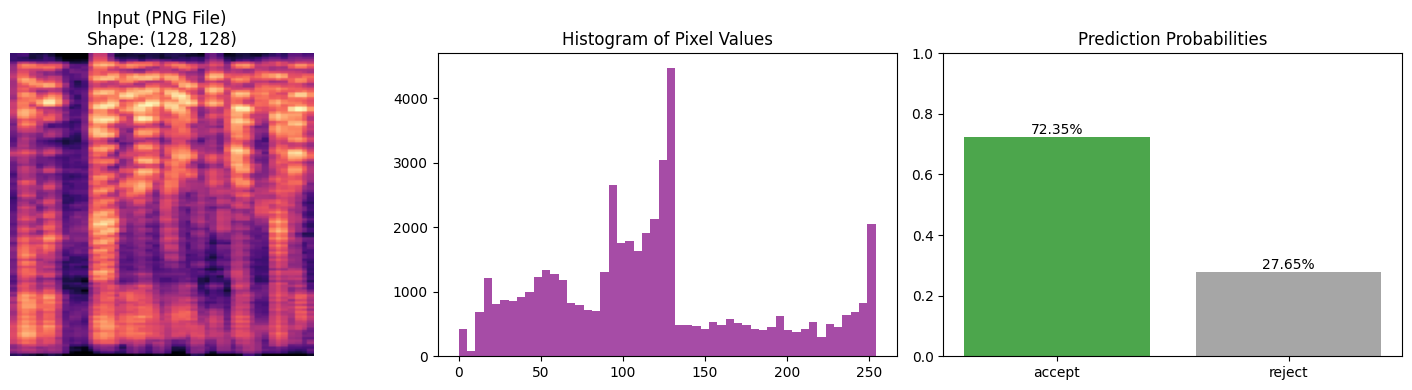


Checking: Artem_Poddierohin_11_0011.png
--- Debug Result ---
Prediction: accept (83.3%)


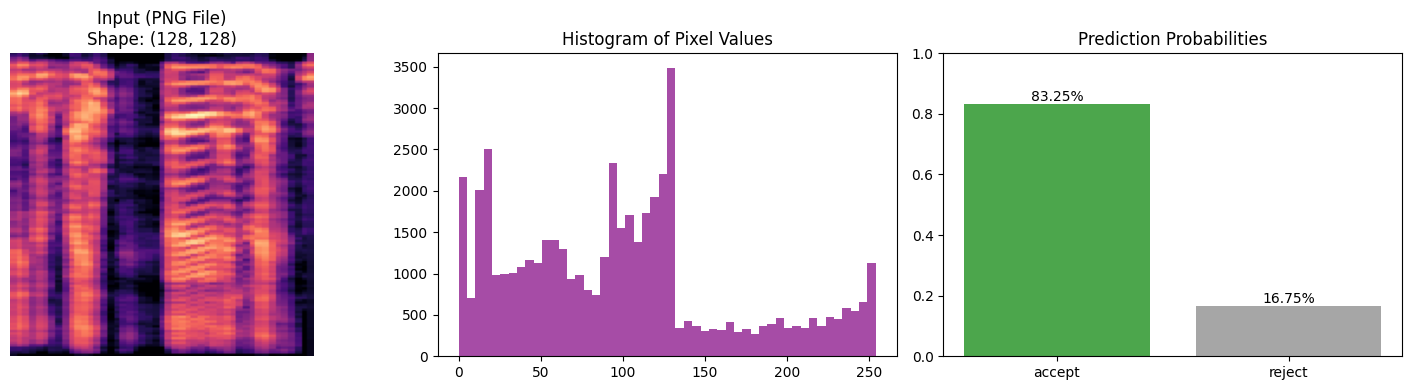


Checking: Artem_Poddierohin_11_0012.png
--- Debug Result ---
Prediction: accept (98.5%)


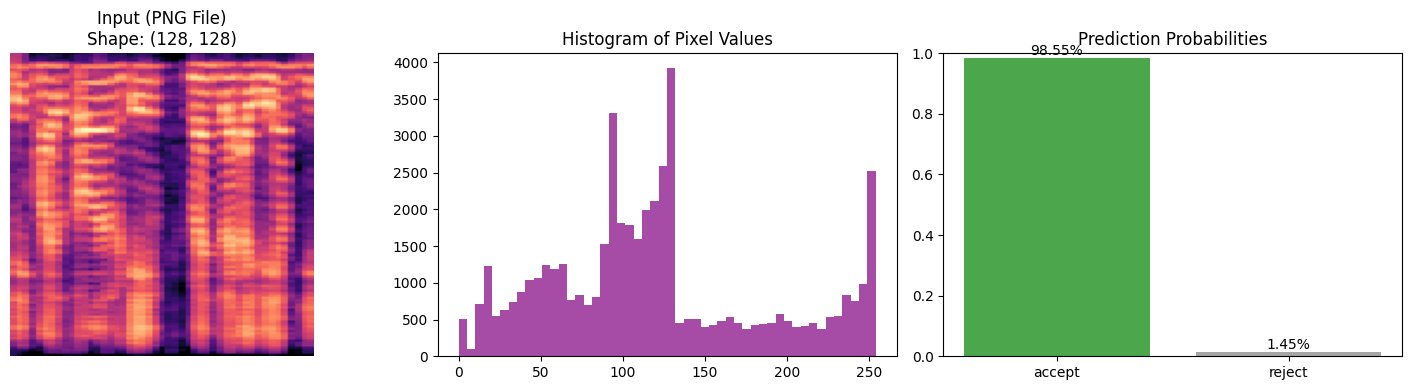

In [52]:
import glob
import os

folder_path = r"C:\Users\ASUS\Desktop\MachineLearning\git\processed\test\accept"

files = glob.glob(os.path.join(folder_path, "*.png"))

print(f"Files found: {len(files)}")

for f in files[10:13]:
    print(f"\nChecking: {os.path.basename(f)}")
    debug_inference(f)

Testing:
 WAV: C:\Users\ASUS\Desktop\MachineLearning\accept\Artem_Poddierohin_3.wav
 PNG: C:\Users\ASUS\Desktop\MachineLearning\git\processed\test\accept\Artem_Poddierohin_8_0000.png


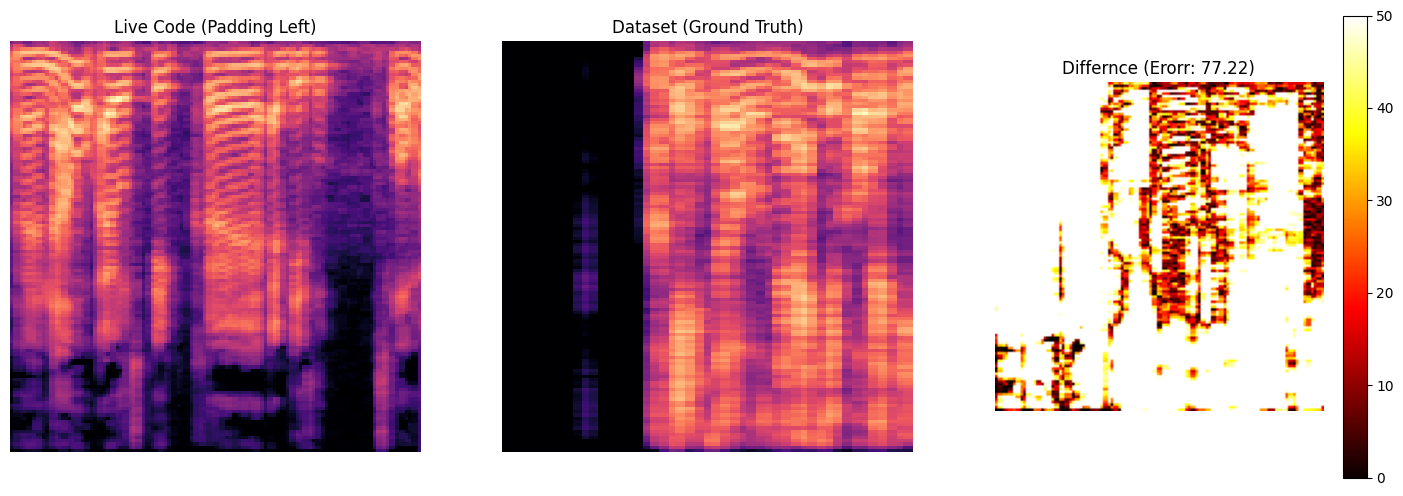

In [46]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display
from PIL import Image
import torch
from torchvision import transforms
import io

def preprocess_audio_correct(y, sr=16000):
    
    y_trimmed, _ = librosa.effects.trim(y, top_db=20)
    
    needed_len = int(3.0 * sr)
    
    if len(y_trimmed) < needed_len:
        
        padding = needed_len - len(y_trimmed)
        y_final = np.pad(y_trimmed, (padding, 0), mode='constant')
    else:
       
        y_final = y_trimmed[:needed_len]
        
    return y_final


def audio_to_image_tensor_replica(y, sr=16000):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=512)
    S_db = librosa.power_to_db(S, ref=np.max)

    fig = plt.figure(figsize=(1.28, 1.28), dpi=100)
    plt.axis("off")
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    
   
    plt.imshow(S_db[::-1, :], aspect="auto", origin="lower",
               interpolation="nearest", cmap="magma")

    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches="tight", pad_inches=0)
    plt.close(fig)
    
    buf.seek(0)
    img = Image.open(buf).convert("RGB").resize((128, 128), resample=Image.Resampling.NEAREST)
    return img

def test_fidelity_fixed(wav_path, png_path):
    print(f"Testing:\n WAV: {wav_path}\n PNG: {png_path}")
    
    y_raw, sr = librosa.load(wav_path, sr=16000)
    
   
    y_processed = preprocess_audio_correct(y_raw, sr)
    
   
    generated_img = audio_to_image_tensor_replica(y_processed, sr)
    
    
    original_img = Image.open(png_path).convert("RGB").resize((128, 128))

    plt.figure(figsize=(18, 6))
    
    plt.subplot(1, 3, 1)
    plt.imshow(generated_img)
    plt.title("Live Code (Padding Left)")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(original_img)
    plt.title("Dataset (Ground Truth)")
    plt.axis("off")
    
  
    gen_arr = np.array(generated_img, dtype=float)
    orig_arr = np.array(original_img, dtype=float)
    diff = np.abs(gen_arr - orig_arr).mean(axis=2)
    
    plt.subplot(1, 3, 3)

    plt.imshow(diff, cmap='hot', vmin=0, vmax=50) 
    plt.title(f"Differnce (Erorr: {diff.mean():.2f})")
    plt.colorbar()
    plt.axis("off")
    
    plt.show()

wav_file = r"C:\Users\ASUS\Desktop\MachineLearning\accept\Artem_Poddierohin_3.wav" 
png_file = r"C:\Users\ASUS\Desktop\MachineLearning\git\processed\test\accept\Artem_Poddierohin_8_0000.png"

test_fidelity_fixed(wav_file, png_file)